In [1]:
import pandas as pd
import numpy as np
import os
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
# 1. 경로 및 데이터 로드
BASE_PATH = r'D:\AiSon\DTS\BDW'
print("🔥 [개별 상품 분석] 데이터 로드 중...")

orders = pd.read_csv(os.path.join(BASE_PATH, 'olist_orders_dataset.csv'))
items = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_items_dataset.csv'))
customers = pd.read_csv(os.path.join(BASE_PATH, 'olist_customers_dataset.csv'))
sellers = pd.read_csv(os.path.join(BASE_PATH, 'olist_sellers_dataset.csv'))
reviews = pd.read_csv(os.path.join(BASE_PATH, 'olist_order_reviews_dataset.csv'))
geo = pd.read_csv(os.path.join(BASE_PATH, 'olist_geolocation_dataset.csv'))
products = pd.read_csv(os.path.join(BASE_PATH, 'olist_products_dataset.csv'))
trans = pd.read_csv(os.path.join(BASE_PATH, 'product_category_name_translation.csv'))

🔥 [개별 상품 분석] 데이터 로드 중...


In [4]:
# 2. 병합 및 거리 계산
df = orders.merge(items, on='order_id')
df = df.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id')
df = df.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id')
df = df.merge(reviews[['order_id', 'review_score']], on='order_id')
products = products.merge(trans, on='product_category_name', how='left')
df = df.merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left')

In [5]:
geo_avg = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
df = df.merge(geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'})
df = df.merge(geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='inner').rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'})

In [6]:
R = 6371
phi1, phi2 = np.radians(df['c_lat']), np.radians(df['s_lat'])
dphi = np.radians(df['s_lat'] - df['c_lat'])
dlambda = np.radians(df['s_lng'] - df['c_lng'])
a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2) * np.sin(dlambda/2)**2
df['distance_km'] = R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

In [7]:
# -------------------------------------------------------------------------
# 3. [핵심 변경] 카테고리가 아니라 'Product_ID' 기준으로 집계
# -------------------------------------------------------------------------
print("🔥 [분석 중] 수만 개의 개별 상품(Product ID)을 전수 조사합니다...")

item_stats = df.groupby(['product_id', 'product_category_name_english']).agg({
    'order_id': 'count',       # 판매량
    'review_score': 'mean',    # 평균 평점
    'distance_km': 'mean',     # 평균 배송 거리
    'price': 'mean'            # 평균 가격
}).reset_index()

item_stats.columns = ['Product_ID', 'Category', 'Volume', 'Score', 'Distance', 'Price']

🔥 [분석 중] 수만 개의 개별 상품(Product ID)을 전수 조사합니다...


In [8]:
# 신뢰도 필터: 최소 5개 이상은 팔린 물건만 분석 (우연히 1개 팔리고 5점 받은거 제외)
valid_items = item_stats[item_stats['Volume'] >= 5]

# 전체 평균 거리 계산
avg_dist = valid_items['Distance'].mean()

In [38]:
# -------------------------------------------------------------------------
# 4. 전략별 개별 상품 추출
# -------------------------------------------------------------------------

# [Hero 상품] 거리 > 평균 & 평점 >= 4.5 (진짜 명품)
hero_items_10 = valid_items[
    (valid_items['Distance'] > avg_dist) & 
    (valid_items['Score'] >= 4.5)
].sort_values(by='Volume', ascending=False).head(10)

In [39]:
hero_display_10 = hero_items_10.copy()
hero_display_10['Short_ID'] = hero_display_10['Product_ID'].str[:8] + "..."

In [41]:
# -------------------------------------------------------------------------
# 5. 결과 출력 (ID 앞 8자리만 보여줌 - 가독성 위해)
# -------------------------------------------------------------------------
print("\n" + "="*80)
print(f"🚀 [전략 1 수정] Hero 개별 상품 TOP 10 (장거리 고만족)")
print("="*80)
print(hero_display_10[['Category', 'Product_ID', 'Volume', 'Distance', 'Score']].to_string(index=False))


🚀 [전략 1 수정] Hero 개별 상품 TOP 10 (장거리 고만족)
             Category                       Product_ID  Volume    Distance    Score
           cool_stuff 5f504b3a1c75b73d6151be81eb05bdc9      63  773.807212 4.555556
          electronics 6a8631b72a2f8729b91514db87e771c0      62  787.329773 4.709677
           housewares d696750e550fd0f733979dd7e5dff921      57  682.305262 4.526316
                 food ed2067a9c1f79553088a3c67b99a9f97      52  599.969201 4.538462
computers_accessories 130482add9fd75ccb6c57ba007694a2d      52 1008.787072 4.538462
                 baby 57e089e3103f5cda6a4ce23b77399bdb      43  694.364680 4.627907
           housewares f8b624d4e475bb8d1bddf1b65c6a64f6      41  696.231485 4.682927
      furniture_decor a237de12bdf0bfe4fe220bae65a89731      36  841.560628 4.527778
                 toys dd6a505f83dd3c6326aa9856519e0978      36  911.833196 4.694444
            telephony e282624d8c82e04983f125e167eb4521      34  684.876803 4.529412


1. Product_ID

"Olist 데이터베이스에 등록된 실제 상품의 주민등록번호(SKU)입니다.

표의 맨 위를 봐주십시오. 5f504b... 라는 코드를 가진 상품이 있습니다. 이 상품은 '쿨 스터프(Cool Stuff)' 카테고리인데, 가격이 약 599헤알(약 14만원)로 꽤 비쌉니다.
놀라운 점은, 고객들이 이 비싼 물건을 받으려고 평균 773km(서울-부산 왕복 거리)를 기다렸고, 평점은 4.55점이나 줬다는 사실입니다.

즉, 이 ID(5f504b...)를 가진 상품은 거리가 멀어도, 비싸도 팔리는 우리 회사의 '슈퍼스타'입니다."

2. 카테고리와 차이점

"아까 보여드린 게 'Category'라는 숲(전체)을 본 거라면, 지금 보시는 건 그 숲에서 가장 높게 자란 나무(특정 인기 상품)를 찍어낸 것입니다.

마케팅 팀에 '쿨 스터프 광고해'라고 하면 막막해하지만, '이 상품코드(5f504b...)를 메인 배너에 걸어'라고 하면 즉시 실행할 수 있습니다. 우리가 찾은 건 바로 그 구체적인 실행 타겟입니다."

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
# 1. 다시 집계 (안전성 확보)
item_stats = df.groupby(['product_id', 'product_category_name_english']).agg({
    'order_id': 'count',       
    'review_score': 'mean',    
    'distance_km': 'mean',     
    'price': 'mean'            
}).reset_index()
item_stats.columns = ['Product_ID', 'Category', 'Volume', 'Score', 'Distance', 'Price']

valid_items = item_stats[item_stats['Volume'] >= 10] # 10개 이상 판매
avg_dist = valid_items['Distance'].mean() # 평균 거리

In [44]:
# 조건: 거리 > 평균 & 평점 >= 4.5
hero_items_10 = valid_items[
    (valid_items['Distance'] > avg_dist) & 
    (valid_items['Score'] >= 4.5)
].sort_values(by='Volume', ascending=False).head(10)  # ★여기를 10으로 바꿨습니다

In [45]:
# 3. 데이터 가공 (ID 줄이기)
hero_display_10 = hero_items_10.copy()
hero_display_10['Short_ID'] = hero_display_10['Product_ID'].str[:8] + "..."

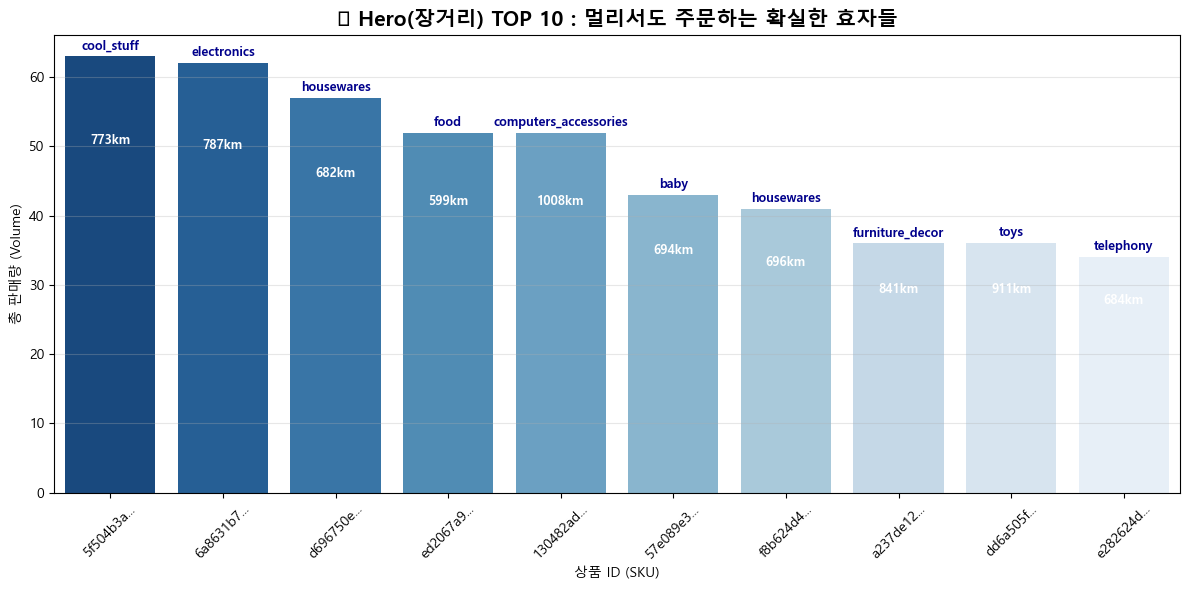

✅ Hero TOP 10 그래프 출력 완료. 이제 위아래 10개씩 딱 맞습니다.


In [46]:
# ------------------------------------------------------------------
# 4. 그래프 그리기 (파란색 테마)
# ------------------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 도화지(fig)와 그림판(ax) 동시 생성 (빈 그래프 방지)
fig, ax = plt.subplots(figsize=(12, 6))
# 막대 그래프 그리기 (Hero니까 파란색 계열 'Blues_r')
sns.barplot(data=hero_display_10, x='Short_ID', y='Volume', palette='Blues_r', ax=ax)

# 막대 위에 정보 표시
for i, p in enumerate(ax.patches):
    if i < len(hero_display_10):
        height = p.get_height()
        category = hero_display_10['Category'].iloc[i]
        distance = hero_display_10['Distance'].iloc[i]
        
        # 1. 카테고리 이름 (진한 파랑)
        ax.text(p.get_x() + p.get_width()/2., height + 1, 
                f"{category}", 
                ha="center", fontsize=9, fontweight='bold', color='darkblue')
        
        # 2. 거리 정보 (흰색)
        ax.text(p.get_x() + p.get_width()/2., height - (height*0.2), 
                f"{int(distance)}km", 
                ha="center", fontsize=9, color='white', fontweight='bold')

# 제목 및 라벨
ax.set_title('🚀 Hero(장거리) TOP 10 : 멀리서도 주문하는 확실한 효자들', fontsize=15, fontweight='bold')
ax.set_xlabel('상품 ID (SKU)')
ax.set_ylabel('총 판매량 (Volume)')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Hero TOP 10 그래프 출력 완료. 이제 위아래 10개씩 딱 맞습니다.")